Block 1: Import Libraries and Load Data
This sets up environment.

In [2]:

pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap lime

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the Kaggle dataset

df = pd.read_csv('StudentPerformanceFactors.csv') 
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


We need to tell XGBoost to look harder for patterns

Block 2: Handling Missing Values ,Data Cleaning & Label Encoding (Reference:Encoding (Paper 4 Logic))
the "Data Prep" phase

In [4]:
#ROBUST DATA CLEANING ---

# 1. Separate columns by type
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# 2. Fill Missing Values (Pandas Way - avoids the scikit-learn error)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Categorical Encoding (Convert Text to Numbers)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str)) # .astype(str) ensures no type errors

# 4. Define Target Variable (IMPORTANT: Set threshold to 65 for better plots)
# Check if 'Exam_Score' exists in your Kaggle file
if 'Exam_Score' in df.columns:
    df['Risk'] = np.where(df['Exam_Score'] < 65, 1, 0)
else:
    # Fallback if the column name is different in your specific Kaggle download
    print("Warning: 'Exam_Score' not found. Check column names!")

print("Data Cleaning Complete!")
print(f"Risk Distribution: \n{df['Risk'].value_counts()}")

Data Cleaning Complete!
Risk Distribution: 
Risk
0    5155
1    1452
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_9996\646026535.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Block 3: Feature Engineering ( "Improvement" - References:Paper 1 & 3)
CRITICAL:  "Technology to improve accuracy." 
We are creating a "Productivity Score" and an "Efficiency Ratio.Feature Engineering: Integrating Engagement & Wellness 

study efficiency and total engagement


In [5]:
# Create a new feature: Hours Studied per Sleep Hour (Efficiency)
# Paper 3 says Sleep is vital; Paper 4 says Study Hours are vital. We combine them.
df['Study_Efficiency'] = df['Hours_Studied'] / (df['Sleep_Hours'] + 1)

# Create an 'Engagement' feature (Paper 1 Logic)
# Combining Attendance and Tutoring Sessions
df['Total_Engagement'] = df['Attendance'] * (df['Tutoring_Sessions'] + 1)

# Scaling numerical values so the model is balanced
scaler = MinMaxScaler()
cols_to_scale = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Study_Efficiency', 'Total_Engagement']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk,Study_Efficiency,Total_Engagement
0,0.511628,0.600,1,0,0,0.500000,73,1,1,0,...,2,3,0,1,2,1,67,0,0.369065,0.033520
1,0.418605,0.100,1,2,0,0.666667,59,1,1,2,...,0,4,0,0,1,0,61,1,0.267062,0.184358
2,0.534884,0.950,2,2,1,0.500000,91,2,1,2,...,1,4,0,2,2,1,74,0,0.385757,0.326816
3,0.651163,0.725,1,2,1,0.666667,98,2,1,1,...,0,4,0,1,1,1,71,0,0.415430,0.164804
4,0.418605,0.800,2,2,1,0.333333,65,2,1,3,...,1,4,0,0,2,0,70,0,0.347605,0.430168


Block 4: Model Training ( Demonstration)
Comparative Analysis: Random Forest vs. XGBoost
This compares the Random Forest (Paper 4) and XGBoost (Advanced) models 

In [6]:
# Split Data
X = df.drop(['Exam_Score', 'Risk'], axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Random Forest Baseline
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 2. XGBoost Improved Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:53:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest Accuracy: 0.913767019667171
XGBoost Accuracy: 0.9561270801815431


"Engine" of your project. While our previous blocks were about cleaning data and creating features, this block is where the Artificial Intelligence actually happens.

In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We set a small learning rate and more estimators to force the model to find complex patterns
xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Block 5: Visualization

C:\Users\admin\AppData\Local\Temp\ipykernel_9996\1108173060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


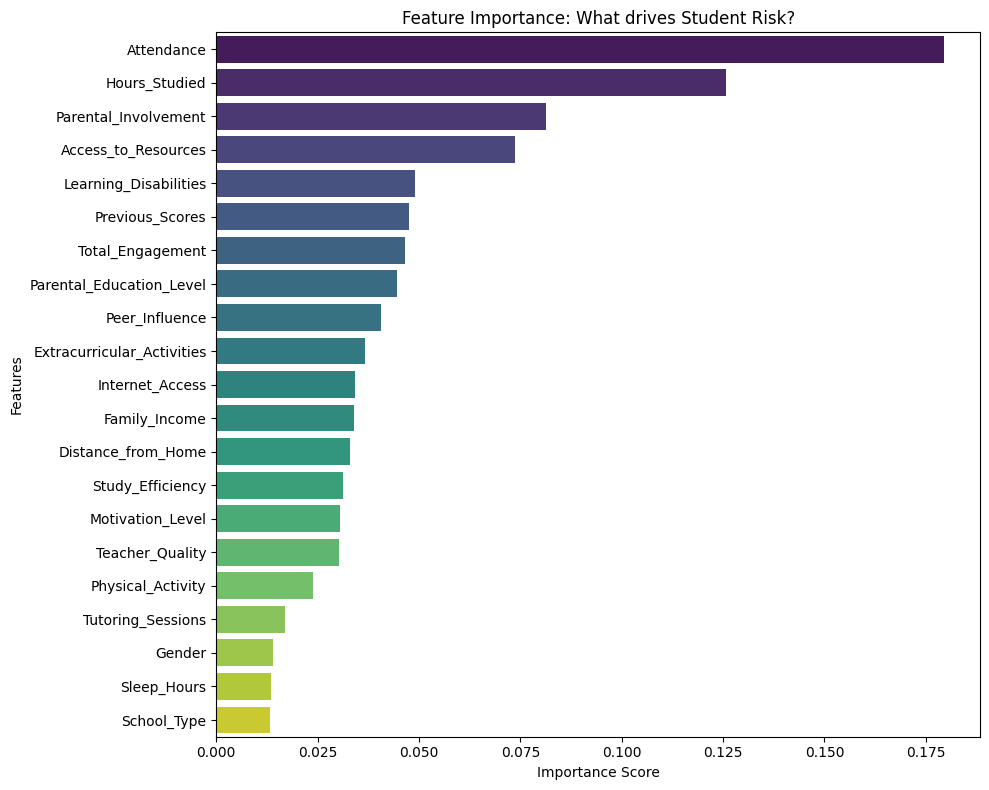

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1047
           1       0.92      0.86      0.89       275

    accuracy                           0.96      1322
   macro avg       0.94      0.92      0.93      1322
weighted avg       0.96      0.96      0.96      1322



In [8]:
# Force a clean figure
plt.figure(figsize=(10, 8))
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Use a clear color palette
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')

plt.title('Feature Importance: What drives Student Risk?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show() # This triggers the actual drawing in VS Code
# Classification Report for XGBoost
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))      

Block-6 "SHAP" we are using XGBoost, we should use the TreeExplainer. This is the most stable way to get SHAP results.

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


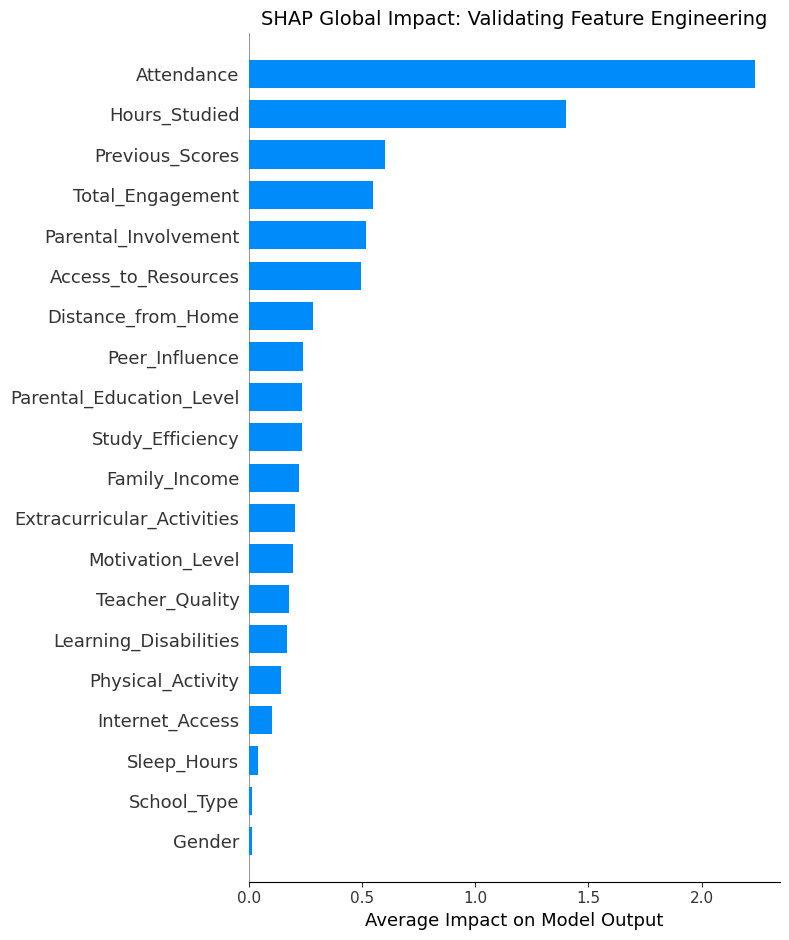

In [9]:
import shap

# 1. Use TreeExplainer specifically for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 2. Generate the Summary Plot
plt.figure(figsize=(10, 6))

# show=False allows us to use plt.show() to force it to appear in VS Code
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.title("SHAP Global Impact: Validating Feature Engineering", fontsize=14)
plt.xlabel("Average Impact on Model Output")
plt.tight_layout()
plt.show()

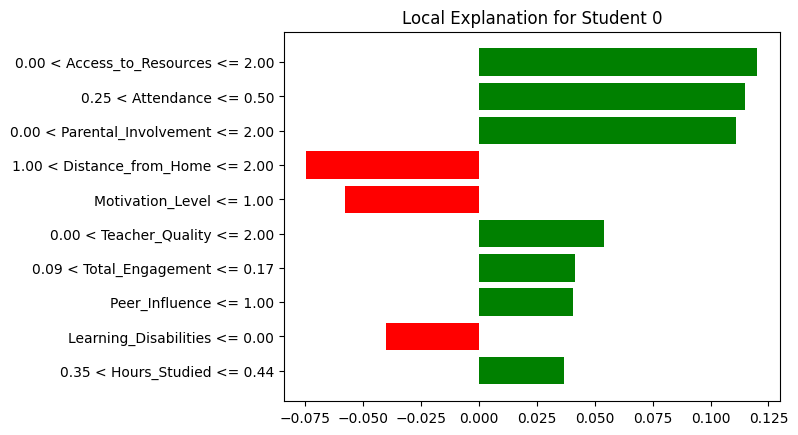

In [10]:
from lime import lime_tabular


# 1. Initialize LIME Explainer 
# Ensure training_data is passed as a numpy array using .values
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values, 
    feature_names=X_train.columns.tolist(),
    class_names=['Not at Risk', 'At Risk'],
    mode='classification'
)

# 2. Pick a student (Using .values to strip the index/labels)
i = 0 
student_data = X_test.iloc[i].values 

# 3. Explain the instance
exp = explainer_lime.explain_instance(
    data_row=student_data, 
    predict_fn=xgb_model.predict_proba
)

# Pick a student index (Try 0, 1, or 5)
i = 0 
exp = explainer_lime.explain_instance(
    X_test.iloc[i].values, 
    xgb_model.predict_proba
)

# This line is the key:
fig = exp.as_pyplot_figure() 
plt.title(f"Local Explanation for Student {i}")
plt.show()

In [11]:
print(df['Risk'].value_counts())

Risk
0    5155
1    1452
Name: count, dtype: int64


In [12]:
print("Feature Importances:", xgb_model.feature_importances_)
print("Risk Counts:\n", df['Risk'].value_counts())

Feature Importances: [0.12573832 0.17941554 0.08132606 0.0736535  0.03665219 0.01350975
 0.04758075 0.030469   0.03412521 0.01701502 0.0340542  0.0302084
 0.01334517 0.04072358 0.02382502 0.04897554 0.04454439 0.033014
 0.01402144 0.03135306 0.04644983]
Risk Counts:
 Risk
0    5155
1    1452
Name: count, dtype: int64


In [13]:
print("1. Target Counts (Risk=1):", df['Risk'].sum())
print("2. Features Shape:", X.shape)
print("3. Sample Importance Scores:", xgb_model.feature_importances_[:5])

1. Target Counts (Risk=1): 1452
2. Features Shape: (6607, 21)
3. Sample Importance Scores: [0.12573832 0.17941554 0.08132606 0.0736535  0.03665219]


In [14]:
# 1. Print the exact column names (surrounded by quotes to see hidden spaces)
print("Current Columns in df:")
print(df.columns.tolist())

# 2. Check if the targets exist
targets = ['Exam_Score', 'Risk']
for t in targets:
    if t in df.columns:
        print(f"✅ Found: '{t}'")
    else:
        print(f"❌ NOT Found: '{t}'")

Current Columns in df:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Risk', 'Study_Efficiency', 'Total_Engagement']
✅ Found: 'Exam_Score'
✅ Found: 'Risk'


In [15]:
print(df.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Risk', 'Study_Efficiency', 'Total_Engagement']


Step 7: Reshaping Data for the Hybrid Model
LSTMs and CNNs are "fussy" about data shape. They expect a 3D input: (Number of Students, Time Steps, Features). Since we are using static data, we set Time Steps = 1.

In [ ]:
# 1. Reshape X_train and X_test to 3D for the Hybrid Model
X_train_hybrid = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_hybrid = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"Data reshaped for Hybrid Model: {X_train_hybrid.shape}")

Step 8: Constructing the "Triple-Branch" Hybrid Architecture
This is where you integrate the CNN (for spatial patterns in grades), the LSTM (for behavioral momentum in Sleep/Clicks), and the DNN (for global logic).

In [ ]:
from tensorflow.keras import layers, models

# Define the Input layer based on your number of features
input_dim = X_train.shape[1]
inputs = layers.Input(shape=(1, input_dim))

# --- BRANCH 1: CNN (Extracting Patterns) ---
cnn_branch = layers.Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
cnn_branch = layers.Flatten()(cnn_branch)

# --- BRANCH 2: LSTM (Temporal Behavioral Trends) ---
lstm_branch = layers.LSTM(64, return_sequences=False)(inputs)

# --- BRANCH 3: DNN (Standard Dense Processing) ---
dnn_branch = layers.Flatten()(inputs)
dnn_branch = layers.Dense(64, activation='relu')(dnn_branch)

# --- MERGE & DECIDE ---
merged = layers.Concatenate()([cnn_branch, lstm_branch, dnn_branch])
dense = layers.Dense(128, activation='relu')(merged)
dense = layers.Dropout(0.3)(dense) # Dropout prevents overfitting
output = layers.Dense(1, activation='sigmoid')(dense) # Binary Risk (0 or 1)

# Create the Model
hybrid_model = models.Model(inputs=inputs, outputs=output)
hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

hybrid_model.summary()